In [1]:
from sympy import symbols,Implies,Eq

In [2]:
x=symbols("x")

In [3]:
pred=Implies(x+2>4,x+3<4)

In [4]:
pred

Implies(x + 2 > 4, x + 3 < 4)

In [5]:
x+2>4

x + 2 > 4

In [6]:
Eq(x+2,3)

Eq(x + 2, 3)

In [7]:
resultats=[pred.subs(x,v) for v in [2,3]]

In [8]:
resultats

[True, False]

In [9]:
p = lambda x, y, z: x**2 + y**2 == z**2

In [10]:
p(1,2,3)

False

In [11]:
x,y,z=symbols("x y z")
pytha=Eq(x**2+y**2,z**2)

In [12]:
pytha

Eq(x**2 + y**2, z**2)

In [13]:
pytha.subs({x:1,y:2,z:3})

False

In [14]:
from z3 import Real, ForAll, Implies, prove

In [15]:
x=Real('x')

In [16]:
prove(ForAll([x], x**2 >= 0))

proved


In [17]:
prove(ForAll([x], Implies(x >= 2, x >= 0)))    

proved


In [18]:
prove(ForAll([x], Implies(x >= 2, x <= 0)))    

counterexample
[]


In [19]:
from z3 import Real,Reals, And, Exists, Solver, Goal, Tactic, sat

In [20]:
x = Real('x')

In [21]:
s = Solver()

In [22]:
s.add(x == -x)

In [23]:
print(s.check())   # sat

sat


In [24]:
print(s.model())   # [x = 0]

[x = 0]


In [25]:
x,y,a=Reals("x y a")

In [26]:
g=Goal()

In [27]:
g.add(Exists([x,y],And(x**2+a*y**2<=1,x-y>=2)))

In [28]:
print(Tactic('qe')(g))

[[Exists([x!2, x!3],
         And(x!2**2 + a*x!3**2 <= 1, x!2 + -1*x!3 >= 2))]]


In [29]:
# Try using 'nlqsat' which is specialized for non-linear real quantifiers
print(Tactic('nlqsat')(g))

[[]]


In [30]:
from z3 import *

x, y, a = Reals('x y a')

# 1. Define the formula with the existential quantifier
expr = Exists([x, y], And(x**2 + a*y**2 <= 1, x - y >= 2))

# 2. Use Z3's dedicated quantifier elimination function helper
# This bypasses Tactic() quirks and forces a clean projection
result = simplify(expr, qe=True)

print(result)
# Expected Output: a <= 1/3

Exists([x, y], And(x**2 + a*y**2 <= 1, x + -1*y >= 2))


In [31]:
from z3 import Ints, Tactic, Exists, And

x, t1, t2 = Ints('x t1 t2')

# Define the quantified expression: Exists x such that t1 < x and x < t2
expr = Exists(x, And(t1 < x, x < t2))

# Apply the 'qe' tactic
qe_tactic = Tactic('qe')
result = qe_tactic(expr)

print(result)


[[t1 + -1*t2 <= -2]]


In [32]:
from z3 import Reals, And, Not, Solver
import numpy as np, matplotlib.pyplot as plt

In [33]:
x, y = Reals('x y')
R1_z3 = (2*x)**2 + y**2 + 2*x*y <= 1
R2_z3 = x**2 + y**2 <= 2

# Exists (x,y): R1 and not R2?
s = Solver()
s.add(And(R1_z3, Not(R2_z3)))
print(s.check())   # unsat  =>  R1 ⊆ R2

unsat


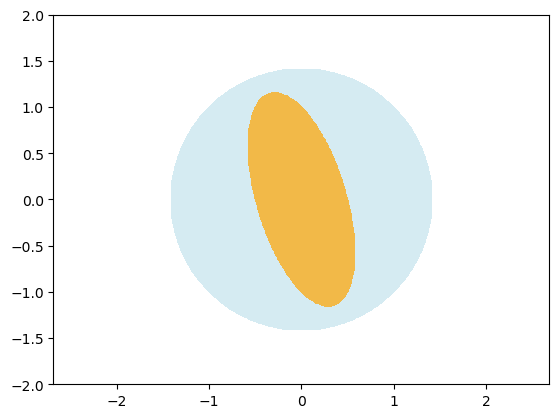

In [36]:
X, Y = np.meshgrid(np.linspace(-2,2,500), np.linspace(-2,2,500))
R1 = (2*X)**2 + Y**2 + 2*X*Y <= 1
R2 = X**2 + Y**2 <= 2
plt.contourf(X, Y, R2, levels=[.5,1.5], colors=['lightblue'], alpha=.5)
plt.contourf(X, Y, R1, levels=[.5,1.5], colors=['orange'],    alpha=.7)
plt.axis('equal'); plt.show()